# BERT Sentiment Analysis with Fine-Tuning and Evaluation

In [2]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")


CUDA available: True
GPU device: NVIDIA GeForce RTX 2050


In [3]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification, AdamW, get_scheduler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from tqdm import tqdm
from transformers import pipeline
from wordcloud import WordCloud
from collections import Counter

## Preprocessing

In [4]:
def preprocess_text(text):
    """ More robust preprocessing to handle empty or malformed data """
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text.strip()


def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

def plot_sentiment_distribution(df, title):
    plt.figure(figsize=(8, 5))
    sns.countplot(x=df['Sentiment'], palette='coolwarm', order=['Positive', 'Neutral', 'Negative'])
    plt.title(title)
    plt.xlabel("Sentiment")
    plt.ylabel("Count")
    plt.show()

def generate_wordcloud(words, title):
    # Check if there are any words to generate the word cloud
    if not words:
        print(f"Warning: No words available for {title}. Skipping word cloud generation.")
        return  # Exit the function if no words are available
    
    # Generate the word cloud if words are available
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(words))
    
    # Plotting the word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(title)
    plt.show()

def plot_top_words(word_frequencies, sentiment):
    if len(word_frequencies) == 0:
        print(f"Warning: No words found for {sentiment} sentiment.")
        return  # Exit the function if no words are available
    
    top_words = sorted(word_frequencies.items(), key=lambda x: x[1], reverse=True)[:10]
    words, freq = zip(*top_words)
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(freq), y=list(words), palette='coolwarm')
    plt.title(f"Top Words Contributing to {sentiment} Sentiment")
    plt.xlabel("Frequency")
    plt.ylabel("Words")
    plt.show()

# Load Datasets and Label Mapping

In [5]:
# Load the updated dataset with sentiment labels
train_df = pd.read_csv("updated_train_dataset.csv")
train_df['Final_Comment'] = train_df['Final_Comment'].astype(str)

# Map sentiment labels to integers
sentiment_mapping = {'NEGATIVE': 0, 'NEUTRAL': 1, 'POSITIVE': 2}
train_df['Sentiment_Label'] = train_df['Sentiment'].map(sentiment_mapping)

# Distribution of sentiments in the updated dataset
print("Train Sentiment Distribution:\n", train_df['Sentiment'].value_counts())


Train Sentiment Distribution:
 Sentiment
NEUTRAL     4037
POSITIVE    2325
NEGATIVE     785
Name: count, dtype: int64


# Fine Tuning BERT model

In [6]:

from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset, random_split
import torch

# Tokenizer and model setup
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=3)

# Custom Dataset Class
class SentimentDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(texts, truncation=True, padding=True, max_length=128)
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

# Prepare data
train_df.dropna(subset=['Sentiment_Label'], inplace=True)
train_df['Sentiment_Label'] = train_df['Sentiment_Label'].astype(int)

dataset = SentimentDataset(train_df['Final_Comment'].tolist(), train_df['Sentiment_Label'].tolist())

# Train/test split
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Training Arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=50,
    weight_decay=0.01,
    evaluation_strategy="epoch",
    logging_dir='./logs',
    logging_steps=10,
    load_best_model_at_end=True,
    save_strategy="epoch"
)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

# Fine-tune the model
trainer.train()

# Evaluate
eval_results = trainer.evaluate()
print("Evaluation Results:", eval_results)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\amirb\PycharmProjects\dataExtractor\.venv\Lib\site-packages\transformers\training_args.py:1594: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,0.094300,0.250188
2,0.131300,0.157949
3,0.045900,0.150435


Evaluation Results: {'eval_loss': 0.15043464303016663, 'eval_runtime': 6.1708, 'eval_samples_per_second': 231.736, 'eval_steps_per_second': 7.292, 'epoch': 3.0}


## BERT Tokenizer and Dataset Preparation

In [7]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.encodings = tokenizer(texts, truncation=True, padding=True, max_length=max_len)
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

texts = train_df['Final_Comment'].astype(str).tolist()
labels = train_df['Sentiment_Label'].tolist()
dataset = SentimentDataset(texts, labels, tokenizer)
loader = DataLoader(dataset, batch_size=16, shuffle=True)


## BERT Model Setup

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=3)
model.to(device)

optimizer = AdamW(model.parameters(), lr=3e-5)
scheduler = get_scheduler("linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=len(loader)*3)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\amirb\PycharmProjects\dataExtractor\.venv\Lib\site-packages\transformers\optimization.py:640: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


## Model Training

In [9]:
# Model Training
model.train()
for epoch in range(5):
    total_loss = 0
    for batch in tqdm(loader, desc=f"Epoch {epoch+1}"):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        total_loss += loss.item()
    print(f"Epoch {epoch+1} Loss: {total_loss / len(loader):.4f}")

Epoch 1: 100%|██████████| 447/447 [01:47<00:00,  4.18it/s]


Epoch 1 Loss: 0.4172


Epoch 2: 100%|██████████| 447/447 [01:46<00:00,  4.19it/s]


Epoch 2 Loss: 0.0947


Epoch 3: 100%|██████████| 447/447 [01:46<00:00,  4.19it/s]


Epoch 3 Loss: 0.0350


Epoch 4: 100%|██████████| 447/447 [01:46<00:00,  4.19it/s]


Epoch 4 Loss: 0.0241


Epoch 5: 100%|██████████| 447/447 [01:46<00:00,  4.19it/s]

Epoch 5 Loss: 0.0242


## Model Evaluation (Testing)

In [10]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in tqdm(loader, desc="Evaluating"):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch['labels'].cpu().numpy())

print("✅ Classification Report on Training Data:")
print(classification_report(all_labels, all_preds))
print("✅ Accuracy:", accuracy_score(all_labels, all_preds))

Evaluating: 100%|██████████| 447/447 [00:28<00:00, 15.62it/s]

✅ Classification Report on Training Data:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       785
           1       1.00      1.00      1.00      4037
           2       1.00      1.00      1.00      2325

    accuracy                           1.00      7147
   macro avg       0.99      0.99      0.99      7147
weighted avg       1.00      1.00      1.00      7147

✅ Accuracy: 0.995802434587939


# Visualizations

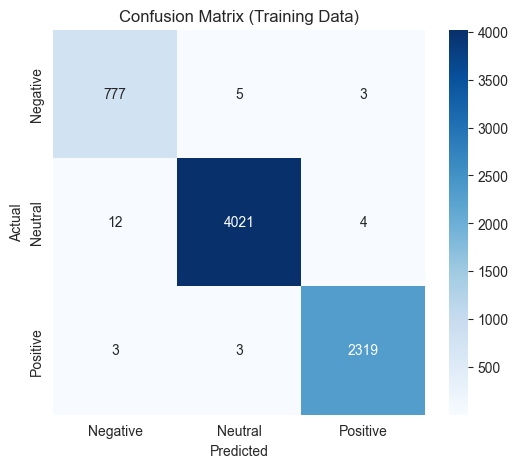

C:\Users\amirb\AppData\Local\Temp\ipykernel_27020\1018887426.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Sentiment'], palette='coolwarm', order=['Positive', 'Neutral', 'Negative'])


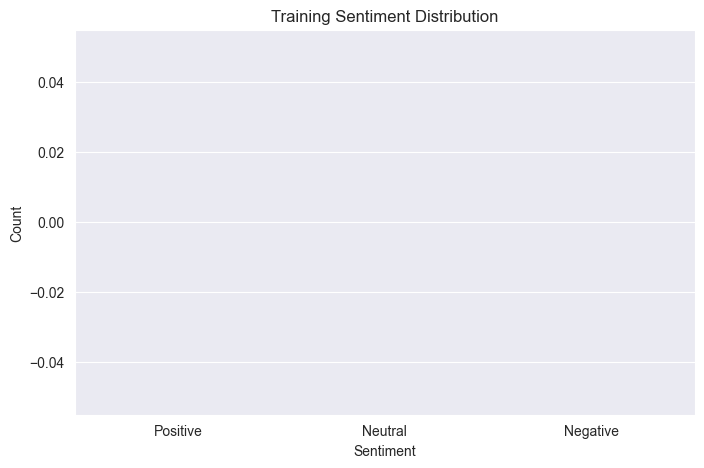

C:\Users\amirb\AppData\Local\Temp\ipykernel_27020\1018887426.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Sentiment'], palette='coolwarm', order=['Positive', 'Neutral', 'Negative'])


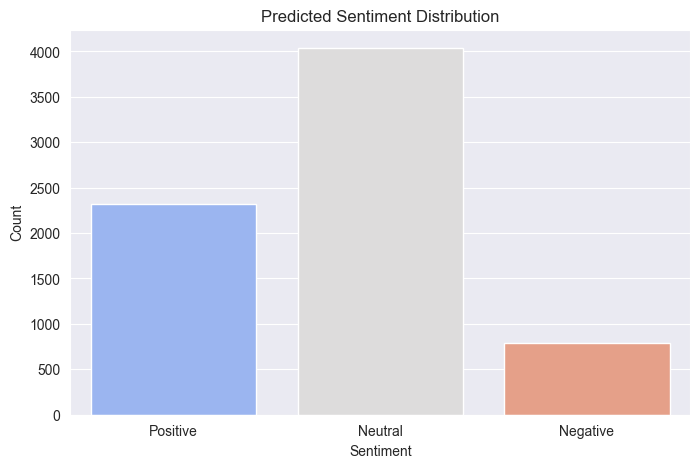

In [11]:
df_eval = pd.DataFrame({'Actual': all_labels, 'Predicted': all_preds})
df_eval['Sentiment'] = df_eval['Actual'].map({0: 'Negative', 1: 'Neutral', 2: 'Positive'})

plot_confusion_matrix(all_labels, all_preds, "Confusion Matrix (Training Data)")
plot_sentiment_distribution(train_df, "Training Sentiment Distribution")
plot_sentiment_distribution(df_eval, "Predicted Sentiment Distribution")


## Saving Model and Tokenizer

In [12]:
torch.save(model.state_dict(), 'bert_finetuned_sentiment.pt')
tokenizer.save_pretrained('./bert_tokenizer')
print("✅ BERT model and tokenizer saved.")

✅ BERT model and tokenizer saved.


# Word Cloud for Each Sentiment

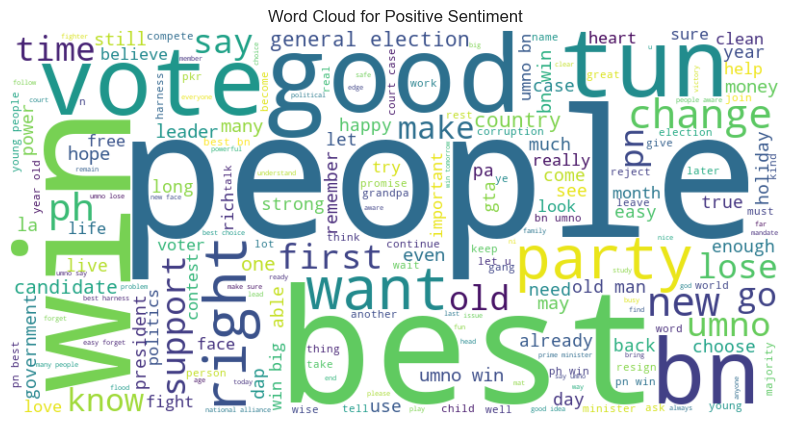

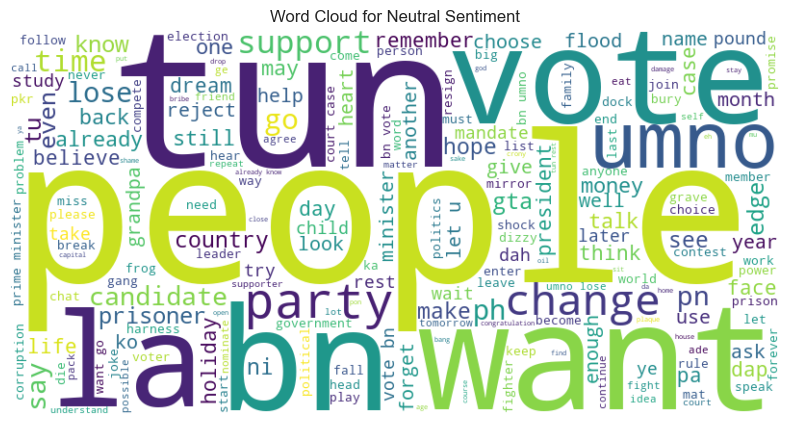

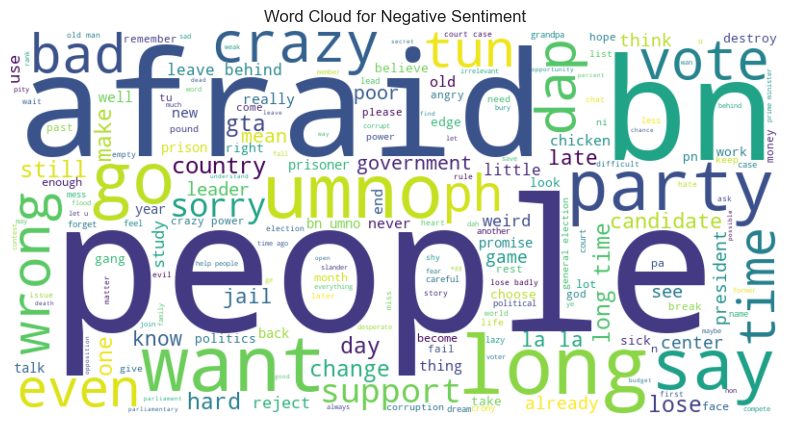

C:\Users\amirb\AppData\Local\Temp\ipykernel_27020\1018887426.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(freq), y=list(words), palette='coolwarm')


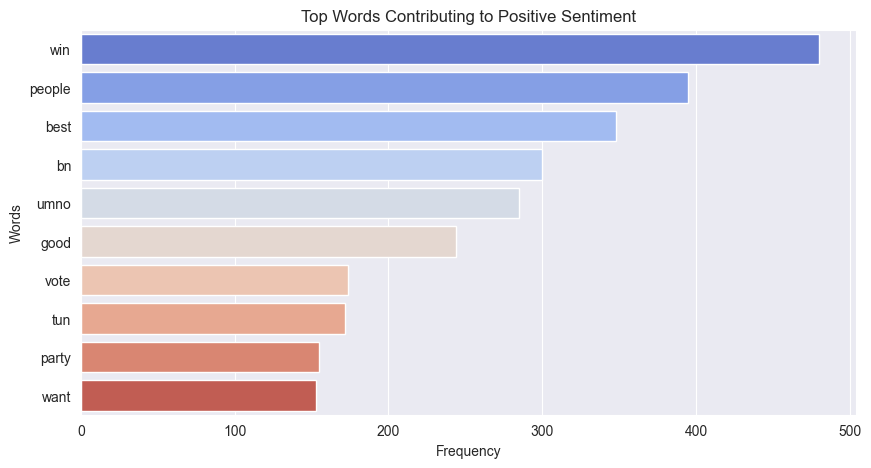

C:\Users\amirb\AppData\Local\Temp\ipykernel_27020\1018887426.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(freq), y=list(words), palette='coolwarm')


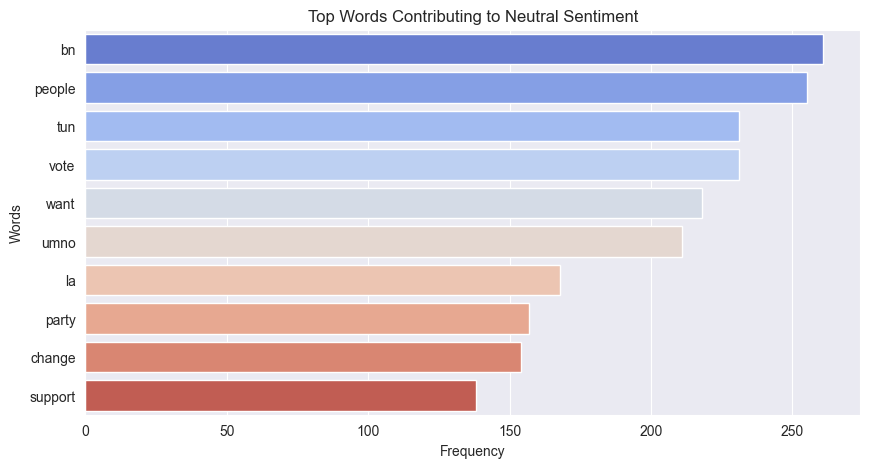

C:\Users\amirb\AppData\Local\Temp\ipykernel_27020\1018887426.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(freq), y=list(words), palette='coolwarm')


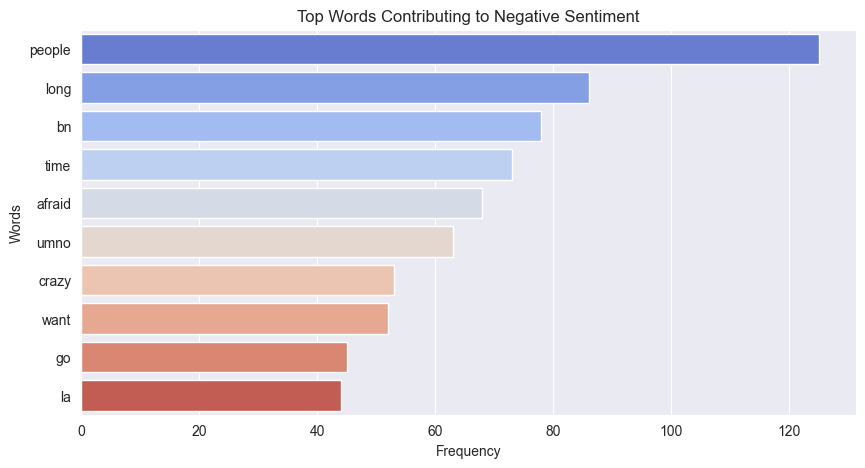

In [13]:
positive_words = ' '.join(train_df[train_df['Sentiment'] == 'POSITIVE']['Final_Comment'].apply(preprocess_text)).split()
neutral_words = ' '.join(train_df[train_df['Sentiment'] == 'NEUTRAL']['Final_Comment'].apply(preprocess_text)).split()
negative_words = ' '.join(train_df[train_df['Sentiment'] == 'NEGATIVE']['Final_Comment'].apply(preprocess_text)).split()

generate_wordcloud(positive_words, "Word Cloud for Positive Sentiment")
generate_wordcloud(neutral_words, "Word Cloud for Neutral Sentiment")
generate_wordcloud(negative_words, "Word Cloud for Negative Sentiment")

plot_top_words(Counter(positive_words), 'Positive')
plot_top_words(Counter(neutral_words), 'Neutral')
plot_top_words(Counter(negative_words), 'Negative')